You might have heard some of us or our PI talks about PCA. But what exactly that is? what do it do?


<br>    


# Dimensionality Reduction for High-Dimensional Data

In this notebook we will introduces three commonly used pattern-recognition / dimensionality-reduction methods for high-dimensional feature tables (e.g., LC-HRMS nontarget feature tables):

1. **PCA (Principal Component Analysis)** — unsupervised, linear. Covered in depth.
2. **PLS-DA (Partial Least Squares Discriminant Analysis)** — supervised, linear. Brief overview.
3. **UMAP (Uniform Manifold Approximation and Projection)** — unsupervised, nonlinear. Brief overview.

since we're just chemist and dont want to get into the math part, I will only introduce about the concepts and some simple code only. 

<br>

But first, what's `demention reduction`?

usually when we work with data for plotting, we're looking at just x and y values. that's 2-dementions, or 2D. easy. 

3D? not much a problem as long as we can get a good angle to look at the 3D graph.


<Br>
but what if you have lots of columns of data, like LCMS which can even have thousands of peaks?

so we need to tranform the data somehow into either 2D or 3D so we as human as work with it more easily. 

you may ask, from thousands of columns reducing to 2 or 3 columns, dont we loss a lot of information?

well, this is the goal of the method: retain as much information as possible while reducing how much we need to work with.



<br>

note:

in this file, i will usually refer variables (individual peaks in our data) as feature.

# Principal Component Analysis (PCA)


PCA is a really common tool for exploratory purpose or looking at a complex data.

as mentioned before, we need to transform high demention data into a few only. in PCA, the new variable constructed is called the principal component, or PC. Each PC is a linear combination of the original features, which present the `directions of the data that explain a maximal amount of variance`. since more variance = more information.

The first PC (PC1) should capture the most variance within the data. the second PC (PC2) should capture the most of the remaining varaince, by being uncorrelated or orthogonal to PC1. PC3 continues the pattern, and so on. usually we stop at 3 since most of the variance should be captured by the first few ones, and we can only visualize up to 3D.

<br>

### so, how does the "directions" come from?

Mechanically, PCA is finding the eigenvectors of the feature covariance matrix, and the corresponding eigenvalues tell you how much variance each eigenvector (PC) accounts for. You don't need the derivation to use this well — the important intuition is:

<br>
eigenvectors = directions <br>
eigenvalues = how much variance is along that direction. 


<br>


after all the math, usually we care about a few things: 

1. Variance explained 

A `scree plot` is usually used for this, which is a bar graph of variance explained vs. PC number. This will tell you how many PC you need to capture enough variance in the data. 

2. visualizing the samples

a lot of time we want to see the groups of sample on PCA to tell if the groups are different or not. a `score plot`, which is PCx vs PCy scatter plot with each sample presented as a single data point.

3. the "loading"

when a PC is constructed, each feature has a coefficient that present the "weight" of the feature in this PC. higher absolute value of this means it contribute more to the variance. This is important for selecting features that's most important


<br>

PCA is scale-sensitive, which matters a lot for MS intensity data. what that means is, when you have peaks that intensity (or area) has large range like from 0 to 1E7, while other may be relatively small from 0 to 1E5, the larger peaks will dominate the varaiance. 

most common way is to do standardize scaling, i.e., make mean = 0 abd standard deviation = 1, with `sklearn.preprocessing. StandardScaler`. this method is also used in other machine learning techniques like K-mean, and SVM. read more in later section as there's assumption about this.

sometime you may choose to use log-tranformation. this does the job of compressing the range of data, but you still need to deal with the mean subtraction after.








Now enough information, lets look into the code...




First of all,  you need to look at your data first. 

we need peaks in the column and sample in the row, but mass spec data is usually reversed, which means you need to transpose your data first. so in that sense, we expected our data to be in the format of X (m by n, or sample x feature) and y (m number of samples). in most of the cases your y is simply the sample name column or the index when put into a DataFrame 

<br><br>


 machine learning codes you see only usually use the cap X for the data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ---------------------------------------------------------
# 1. Mocking  LC-MS Data
# 40 samples (20 Wood Smoke, 20 Plastic Smoke), 3000 m/z features
# ---------------------------------------------------------
np.random.seed(666)
n_features = 3000

# Generating overlapping background noise, with a few distinct features
wood_data = np.random.rand(20, n_features) * 50
plastic_data = np.random.rand(20, n_features) * 50

# Injecting 'biomarkers' (features that actually differ between groups)
wood_data[:, 10:20] += 30  # Wood has higher abundance in features 10-19
plastic_data[:, 40:50] += 30 # Plastic has higher abundance in features 40-49

data = np.vstack((wood_data, plastic_data))
labels = ['Wood'] * 20 + ['Plastic'] * 20

df = pd.DataFrame(data, columns=[f'mz_{i}' for i in range(n_features)])
df['Condition'] = labels


In [ ]:
X = df.drop('Condition', axis=1)

y = np.array([0 if label == 'Wood' else 1 for label in df['Condition']])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
scores = pca.fit_transform(X_scaled)

scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(scores.shape[1])],
    index=X.index,)
scores_df["group"] = y

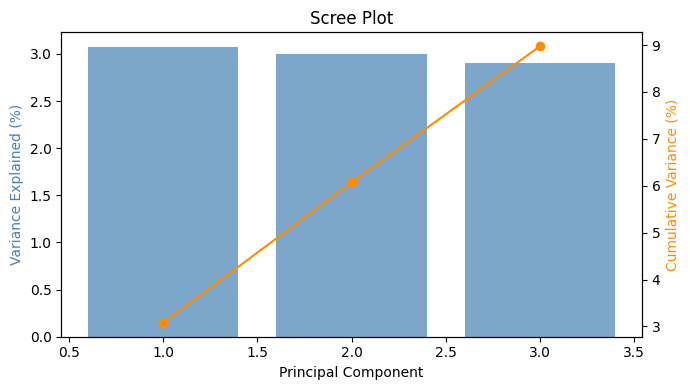

In [13]:
# the scree plot
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(range(1, len(explained_var) + 1), explained_var, color="steelblue", alpha=0.7)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(range(1, len(explained_var) + 1), cumulative_var, color="darkorange", marker="o")
ax2.set_ylabel("Cumulative Variance (%)", color="darkorange")

plt.title("Scree Plot")
plt.tight_layout()
plt.show()

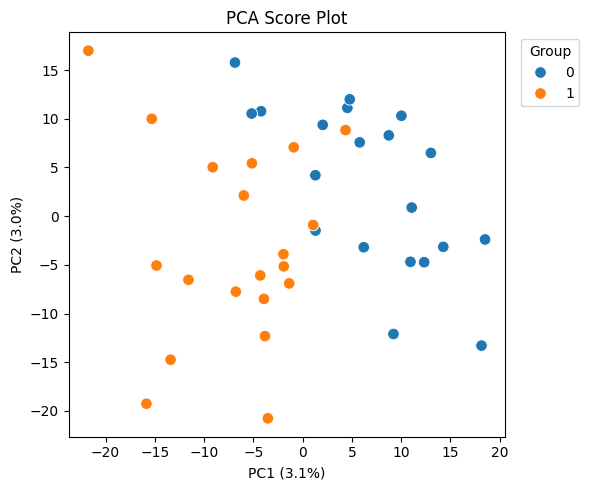

In [14]:
# the score plot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue="group", s=70)
plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
plt.title("PCA Score Plot")
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

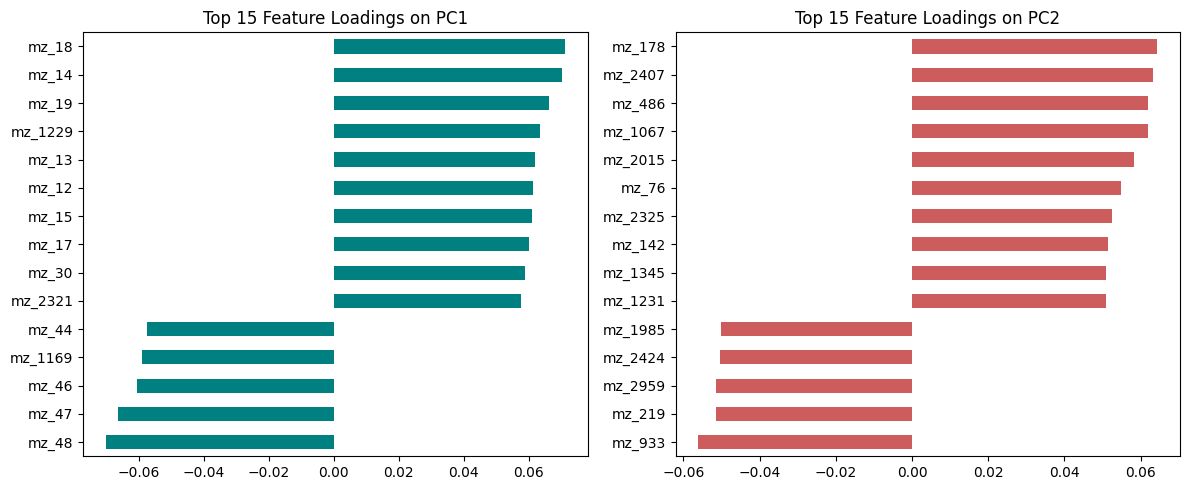

In [15]:
# the loading
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=X.columns,
)

top_n = 15
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(top_n).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(top_n).index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
loadings.loc[top_pc1, "PC1"].sort_values().plot.barh(ax=axes[0], color="teal")
axes[0].set_title(f"Top {top_n} Feature Loadings on PC1")

loadings.loc[top_pc2, "PC2"].sort_values().plot.barh(ax=axes[1], color="indianred")
axes[1].set_title(f"Top {top_n} Feature Loadings on PC2")

plt.tight_layout()
plt.show()

### So PCA looks nice, but what we should be careful about?


##### the arch effect (or horseshoe effect)

This happens your PCA plot has a U- or arc shape distribution of samples. 

PCA is a linear dimensionality reduction technique. It assumes that the relationships between your variables (e.g., the mass features detected) are linear. When your data contains a dominant, underlying non-linear gradient, PCA struggles to represent it accurately on a 2D plane. Instead of showing a straight line across PC1, the algorithm is forced to bend the gradient across both PC1 and PC2 to capture the variance, resulting in that sweeping arc.

so what happened? 

1. there could be extreme concentration or signal differences. this could happen with a clean blank vs heavily loaded sample
2. progression in sample, such as samples of burn from begining to smouldering which some compounds appear or disappear
3. similar to point 2, your insturment may prodoce something similar due to contamination or drifting


is this really mean your data is bad? __not always__, but worth examine the data again


potential solution:
1. see if there's any extreme cases/peaks in the sample, then rethink about normalization (since we always do stadardscalor, it may not be the best way), sometime log tranformation may help. or if blank is the issue, remove it and plot again.

2. PCA simply may not be the right tool to use, try other non-linear methods

### about standardscaler 


standardscaler is normally used in PCA (like the standard way to use it in general), espeically the examples usually came from something like biological (weight, height, certain traits etc). but standardscaler works for __normal distributed__ data and it's __sensitive to outliers__. 

so if you know your data is not going to be normally distributed, it's good to consider using other scalers.


there's a good comparison about scalers: 

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#plot-all-scaling-standard-scaler-section

# Principal Coordinates Analysis (PCOA)


instead of feeding the standardized data to use Euclidean distnece, we can of course do other math... this is where we do PCOA, or sometime refers to `Multi-dimensional Scaling` or MDS as in the sklearn package. 

what it means by "distance" is really "how different are things?". or imagine it's "how far two things are" but in the mathmitical world


if we do PCOA with Euclidean  distence, this is basically PCA
the key difference are:

1. PCOA works backwards, which we compute the distance first, then get to low demensions that preserve the distance
2. PCA is only Euclidean, where PCOA accepts others

so in that sense, we actually "fix" the distance matrix 

### Bray-Curtis

this is basically "what fraction of your total signal is different". It only cares about the shared features' relative sizes — it doesn't do anything special about zeros, it just naturally down-weights them since a feature that's absent in both contributes nothing to the difference.


- still kind of linear which tends to be dominated by your highest-abundance features unless you've already normalized hard.
- care less about rare features
- this is more common in ecology/microbiome 



### Hellinger 


this is similart to PCA which also uses Euclidean distence, but with square root and normalize by sum of the data first. 

- it compresses large values and stretches apart small ones, which specifically fixes the "double-zero problem": in raw Euclidean distance, two samples that both lack a rare compound look artificially similar (they agree on a zero), but after square-rooting, small nonzero values are pulled apart from true zeros instead of getting crushed toward them.
-  do square root first on data +  PCA = PCOA with Hellinger distance matrix
- may use when you suspect there's rare and low abundance feature that are actually important 

In [ ]:
def hellinger_transform(df):
    # Step 1: relative abundance within each sample (column-wise normalization)
    col_sums = df.sum(axis=0)  # one sum per sample
    rel_abundance = df.div(col_sums, axis=1)  # divide each column by its own sum

    # Step 2: square root
    hellinger = np.sqrt(rel_abundance)

    return hellinger

in PCOA or the actual MDS, we can specify the way we calculate the distance matrix. 

but, MDS only accepts a few if you throw in the data. but we can pre-compute the matrix in any form we wanted. read the sklearn documentation here:

https://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling


https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html#sklearn.manifold.MDS

<br>

for the distance metrix calculation, you might want to check out pdist page :https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html






In [ ]:
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
import pandas as pd

# Assuming 'df' has samples as rows and features as columns.
# (If your features are in rows, use df.T instead)
def run_pcoa(df, sample_in_row=True, log_transform=True, metric='braycurtis'):

    df.fillna(0,inplace=True)
    if not sample_in_row:
        df_t = df.T
    else:
        df_t = df
        
    if log_transform:
        df_t = np.log10(df_t + 1)

    df_t.sort_index(inplace=True)


    bc_distances = pdist(df.values, metric=metric)
    distance_matrix = squareform(bc_distances)

    pcoa_model = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    pcoa_coordinates = pcoa_model.fit_transform(distance_matrix)

    pcoa_df = pd.DataFrame(data=pcoa_coordinates, columns=['PCo1', 'PCo2'])
    pcoa_df.index = df.index 
    return pcoa_df

def plot_pcoa_results(pcoa_df, grouping_list, ax, title):
    sns.scatterplot(data=pcoa_df, 
                    x="PCo1",
                    y="PCo2",
                    hue=grouping_list,
                    s=50, alpha=0.85,
                    ax=ax)
    ax.set_title(title)




# Partial least squares discriminant analysis (PLS-DA)




recommended reading:

https://doi.org/10.1002/cem.2609


Top 10 Most Important m/z Features:
   Feature  Coefficient
19   mz_19    -0.004736
45   mz_45     0.004719
11   mz_11    -0.004660
15   mz_15    -0.004647
49   mz_49     0.004553
46   mz_46     0.004425
41   mz_41     0.004386
13   mz_13    -0.004297
10   mz_10    -0.004294
17   mz_17    -0.004251


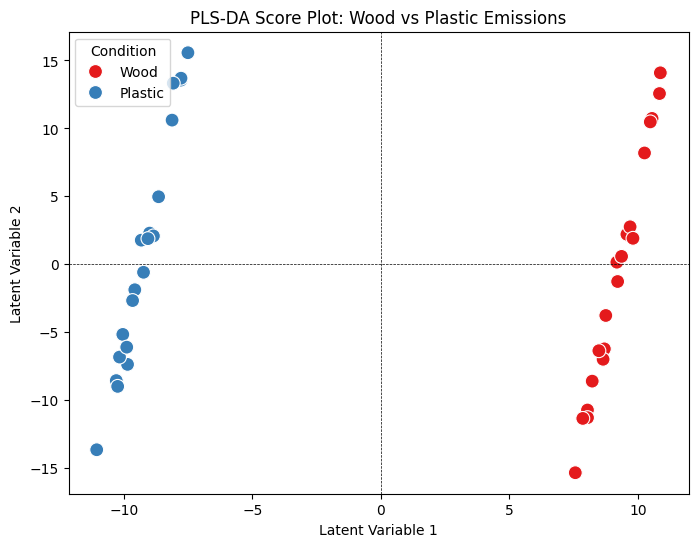

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1. Mocking Aerosolomics LC-MS Data
# 40 samples (20 Wood Smoke, 20 Plastic Smoke), 3000 m/z features
# ---------------------------------------------------------
np.random.seed(666)
n_features = 3000

# Generating overlapping background noise, with a few distinct features
wood_data = np.random.rand(20, n_features) * 50
plastic_data = np.random.rand(20, n_features) * 50

# Injecting 'biomarkers' (features that actually differ between groups)
wood_data[:, 10:20] += 30  # Wood has higher abundance in features 10-19
plastic_data[:, 40:50] += 30 # Plastic has higher abundance in features 40-49

data = np.vstack((wood_data, plastic_data))
labels = ['Wood'] * 20 + ['Plastic'] * 20

df = pd.DataFrame(data, columns=[f'mz_{i}' for i in range(n_features)])
df['Condition'] = labels

# ---------------------------------------------------------
# 2. Preprocessing & Label Encoding
# ---------------------------------------------------------
X = df.drop('Condition', axis=1)

# Supervised models require numerical labels (Wood = 0, Plastic = 1)
Y = np.array([0 if label == 'Wood' else 1 for label in df['Condition']])

# Scaling is mandatory for MS data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# 3. Fitting the PLS-DA Model
# ---------------------------------------------------------
# We extract 2 "Latent Variables" (similar to Principal Components)
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, Y)

# Get the scores (coordinates for the scatter plot)
X_scores, _ = pls.transform(X_scaled, Y)
df['LV1'] = X_scores[:, 0]
df['LV2'] = X_scores[:, 1]

# ---------------------------------------------------------
# 4. Finding Important Features (Coefficients)
# ---------------------------------------------------------
# Extract the regression coefficients. The larger the absolute value, 
# the more important the m/z feature is for separating the groups.
coefficients = pls.coef_.flatten()

# Create a DataFrame to rank the features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

# Sort by most important
top_features = feature_importance.sort_values(by='Absolute_Importance', ascending=False).head(10)
print("Top 10 Most Important m/z Features:")
print(top_features[['Feature', 'Coefficient']])

# ---------------------------------------------------------
# 5. Plotting the PLS-DA Scores
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x='LV1', y='LV2', hue='Condition', data=df, palette='Set1', s=100)
plt.title('PLS-DA Score Plot: Wood vs Plastic Emissions')
plt.xlabel('Latent Variable 1')
plt.ylabel('Latent Variable 2')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.show()